# MNIST Image Denoising Using Convolutional Autoencoders

**Assignment:** Deep Learning — Image Denoising with Autoencoders  
**Dataset:** MNIST (loaded from local directory via KaggleHub)  
**Framework:** PyTorch  

---

## Overview

In this notebook, we build and compare **two Convolutional Autoencoder architectures** for the task of **image denoising**.  
The models are trained to recover clean handwritten digit images from artificially noisy inputs.

| Model | Decoder Strategy |
|---|---|
| Model 1 | Transposed Convolution (ConvTranspose2d) |
| Model 2 | Nearest-Neighbor Upsample + Conv2d |

Both models share an **identical encoder** for a fair comparison.

---
## 1. Imports & Setup

In [4]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import kagglehub

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


---
## 2. Dataset Loading

The MNIST dataset is downloaded via **KaggleHub** and loaded using `torchvision.datasets.ImageFolder`.  
Each image is:
- Resized to **28×28**
- Converted to **grayscale**
- Converted to a tensor and **normalized to [0, 1]**

In [5]:
import kagglehub
import os

path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Base path:", path)

# Walk the directory to see the actual structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # only show files 2 levels deep
        for f in files[:3]:
            print(f"  {indent}{f}")

Base path: C:\Users\devan\.cache\kagglehub\datasets\awsaf49\mnist-dataset\versions\1
1/
  mnist_png/
    testing/
      0/
      1/
      2/
      3/
      4/
      5/
      6/
      7/
      8/
      9/
    training/
      0/
      1/
      2/
      3/
      4/
      5/
      6/
      7/
      8/
      9/


In [6]:
# ── Download dataset ─────────────────────────────────────────────────────────
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Dataset path:", path)

# Locate train/test subdirectories
train_dir = os.path.join(path, "mnist_png", "training")
test_dir  = os.path.join(path, "mnist_png", "testing")

# ── Transforms ───────────────────────────────────────────────────────────────
# Grayscale + resize + tensor; values naturally fall in [0,1] after ToTensor()
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # ensure single channel
    transforms.Resize((28, 28)),                   # standardize to 28×28
    transforms.ToTensor(),                         # [0,255] → [0.0, 1.0]
])

# ── Load datasets ─────────────────────────────────────────────────────────────
full_train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset       = datasets.ImageFolder(root=test_dir,  transform=transform)

# Split training set → 80% train / 20% validation
val_size   = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

Dataset path: C:\Users\devan\.cache\kagglehub\datasets\awsaf49\mnist-dataset\versions\1
Train samples : 48000
Val   samples : 12000
Test  samples : 10000


In [7]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 20
LEARNING_RATE = 0.001
NOISE_FACTOR = 0.4   # std-dev of Gaussian noise

# ── Data loaders ─────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready.")

DataLoaders ready.


---
## 3. Dataset Exploration

A quick look at random samples from the training set.

C:\Users\devan\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


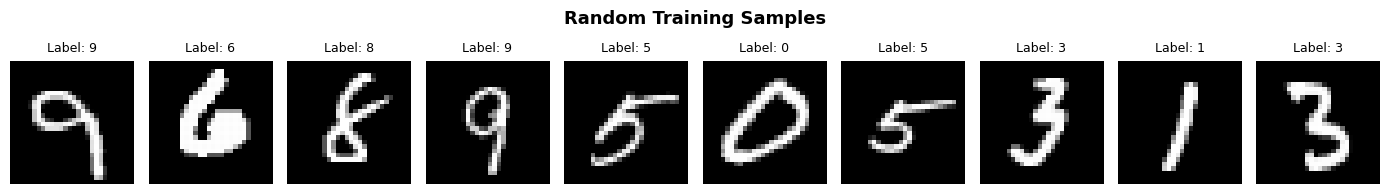

In [8]:
def show_samples(loader, n=10, title="Random Dataset Samples"):
    """Display n random clean images from a DataLoader."""
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    fig, axes = plt.subplots(1, n, figsize=(14, 2))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap="gray")
        ax.set_title(f"Label: {labels[i].item()}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_loader, n=10, title="Random Training Samples")

---
## 4. Noise Generation

### Why add Gaussian noise?

Autoencoders trained on **clean → clean** pairs simply learn an identity function.  
By corrupting the input with **Gaussian noise** (zero-mean, small standard deviation),  
we force the model to learn meaningful latent features that capture the underlying structure  
of the data rather than memorising pixel values.

$$\tilde{x} = x + \mathcal{N}(0,\, \sigma^2) \quad \text{clamped to } [0, 1]$$

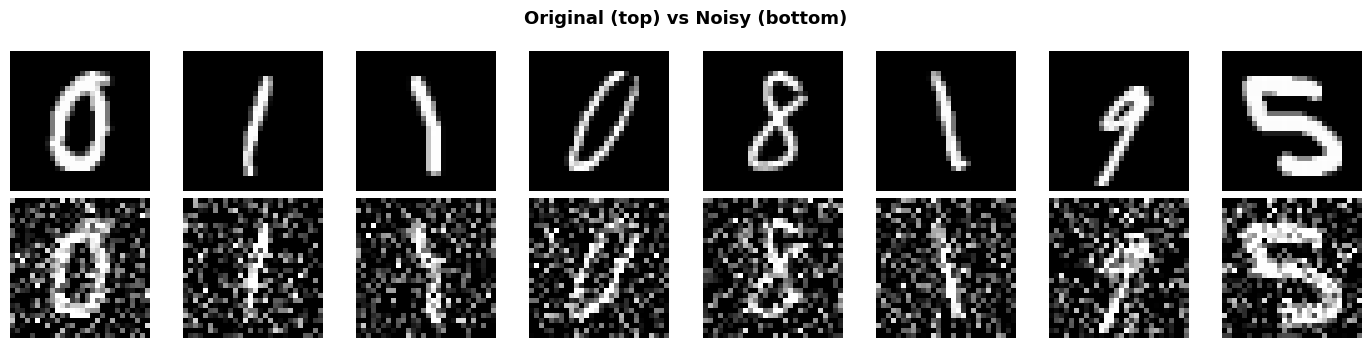

In [9]:
def add_noise(images, noise_factor=NOISE_FACTOR):
    """
    Add Gaussian noise to a batch of images.
    Args:
        images      : clean image tensor  (B, C, H, W) in [0,1]
        noise_factor: std-dev of noise
    Returns:
        noisy images clamped to [0,1]
    """
    noise       = torch.randn_like(images) * noise_factor
    noisy_images = torch.clamp(images + noise, 0.0, 1.0)
    return noisy_images


def show_noisy_comparison(loader, n=8):
    """Visualise original vs noisy images side by side."""
    images, _ = next(iter(loader))
    images    = images[:n]
    noisy     = add_noise(images)

    fig, axes = plt.subplots(2, n, figsize=(14, 3.5))
    fig.suptitle("Original (top) vs Noisy (bottom)", fontsize=13, fontweight="bold")
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy[i].squeeze(), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("Clean",  fontsize=10)
    axes[1, 0].set_ylabel("Noisy",  fontsize=10)
    plt.tight_layout()
    plt.show()

show_noisy_comparison(train_loader)

---
## 5. What is an Autoencoder?

An **Autoencoder** is an unsupervised neural network trained to reconstruct its own input.  
It consists of two parts:

- **Encoder** — compresses the input into a lower-dimensional **latent representation** (bottleneck).
- **Decoder** — reconstructs the original input from the latent code.

```
Input Image  ──►  Encoder  ──►  Latent Code  ──►  Decoder  ──►  Reconstructed Image
```

In a **Denoising Autoencoder**, the input is a *corrupted* version of the image  
and the target is the *clean* version. This forces the model to learn robust features.

### Why MSELoss?

We are comparing pixel intensities — a **regression** problem.  
MSE (Mean Squared Error) penalises large pixel-level deviations more heavily and is the  
natural choice for reconstruction quality:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \hat{x}_i)^2$$

---
## 6. Model Architectures

### Shared Encoder

Both models use an **identical encoder** so that decoder differences drive the comparison.

```
Input: (B, 1, 28, 28)
  Conv2d(1→16, 3×3, pad=1)  →  ReLU  →  MaxPool2d(2)   →  (B, 16, 14, 14)
  Conv2d(16→4, 3×3, pad=1)  →  ReLU  →  MaxPool2d(2)   →  (B,  4,  7,  7)  ← latent
```

### Model 1 Decoder — ConvTranspose2d

```
(B, 4, 7, 7)
  ConvTranspose2d(4→16, 2×2, stride=2)  →  ReLU   →  (B, 16, 14, 14)
  ConvTranspose2d(16→1, 2×2, stride=2)  →  Sigmoid →  (B,  1, 28, 28)
```

### Model 2 Decoder — Upsample + Conv2d

```
(B, 4, 7, 7)
  Upsample(scale=2, nearest)  →  Conv2d(4→16, 3×3, pad=1)  →  ReLU   →  (B, 16, 14, 14)
  Upsample(scale=2, nearest)  →  Conv2d(16→1, 3×3, pad=1)  →  Sigmoid →  (B,  1, 28, 28)
```

### ConvTranspose2d vs Upsample + Conv2d

| Feature | ConvTranspose2d | Upsample + Conv2d |
|---|---|---|
| Upscaling method | Learned (stride convolution) | Fixed (nearest / bilinear) |
| Parameters | More | Fewer |
| Checkerboard artifacts | Possible | Minimal |
| Flexibility | High | High |

**Checkerboard artifacts** in transposed convolutions occur because overlapping kernel regions receive unequal gradient contributions, creating a periodic pattern in the output. Upsampling followed by a regular convolution distributes information more uniformly and largely avoids this issue.

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Shared Encoder
# ═══════════════════════════════════════════════════════════════════════════════
class Encoder(nn.Module):
    """Shared convolutional encoder for both autoencoder models."""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            # Block 1: 28×28 → 14×14
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (B, 16, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (B, 16, 14, 14)

            # Block 2: 14×14 → 7×7  (latent)
            nn.Conv2d(16, 4, kernel_size=3, padding=1),  # (B, 4, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # (B, 4,  7,  7)
        )

    def forward(self, x):
        return self.encoder(x)


# ═══════════════════════════════════════════════════════════════════════════════
#  Model 1 — Transposed CNN Autoencoder
# ═══════════════════════════════════════════════════════════════════════════════
class TransposedCNNAutoencoder(nn.Module):
    """
    Decoder uses ConvTranspose2d layers to upsample back to 28×28.
    ConvTranspose2d is the 'learnable' transpose convolution and doubles
    spatial dimensions when stride=2, kernel=2.
    """

    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = nn.Sequential(
            # Block 1: 7×7 → 14×14
            nn.ConvTranspose2d(4, 16, kernel_size=2, stride=2),  # (B, 16, 14, 14)
            nn.ReLU(),

            # Block 2: 14×14 → 28×28
            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),  # (B,  1, 28, 28)
            nn.Sigmoid(),   # output in [0,1] to match normalised pixel values
        )

    def forward(self, x):
        z = self.encoder(x)   # encode
        return self.decoder(z) # decode


# ═══════════════════════════════════════════════════════════════════════════════
#  Model 2 — Upsampled CNN Autoencoder
# ═══════════════════════════════════════════════════════════════════════════════
class UpsampledCNNAutoencoder(nn.Module):
    """
    Decoder uses nearest-neighbour Upsample followed by Conv2d.
    This avoids the checkerboard artifacts that ConvTranspose2d can produce.
    """

    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = nn.Sequential(
            # Block 1: 7×7 → 14×14
            nn.Upsample(scale_factor=2, mode="nearest"),         # (B, 4, 14, 14)
            nn.Conv2d(4, 16, kernel_size=3, padding=1),          # (B, 16, 14, 14)
            nn.ReLU(),

            # Block 2: 14×14 → 28×28
            nn.Upsample(scale_factor=2, mode="nearest"),         # (B, 16, 28, 28)
            nn.Conv2d(16, 1, kernel_size=3, padding=1),          # (B,  1, 28, 28)
            nn.Sigmoid(),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# ── Quick sanity check ────────────────────────────────────────────────────────
dummy = torch.zeros(1, 1, 28, 28)
m1 = TransposedCNNAutoencoder()
m2 = UpsampledCNNAutoencoder()

assert m1(dummy).shape == (1, 1, 28, 28), "Model 1 output shape mismatch"
assert m2(dummy).shape == (1, 1, 28, 28), "Model 2 output shape mismatch"

print("Model 1 — TransposedCNNAutoencoder")
print(m1)

print("\nModel 2 — UpsampledCNNAutoencoder")
print(m2)

Model 1 — TransposedCNNAutoencoder
TransposedCNNAutoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)

Model 2 — UpsampledCNNAutoencoder
UpsampledCNNAutoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 4, kernel

In [11]:
# ── Parameter counts ─────────────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model 1 trainable parameters: {count_params(m1):,}")
print(f"Model 2 trainable parameters: {count_params(m2):,}")

Model 1 trainable parameters: 1,077
Model 2 trainable parameters: 1,477


---
## 7. Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Run one full training epoch.
    Returns: average training loss for the epoch.
    """
    model.train()
    epoch_loss = 0.0

    for images, _ in loader:            # labels not needed (unsupervised)
        images = images.to(device)
        noisy  = add_noise(images).to(device)   # corrupt input

        optimizer.zero_grad()
        reconstructed = model(noisy)            # forward pass
        loss = criterion(reconstructed, images) # compare to CLEAN target
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)

    return epoch_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    """
    Evaluate the model on a given DataLoader (val or test).
    Returns: average loss (no gradient updates).
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            noisy  = add_noise(images).to(device)

            reconstructed = model(noisy)
            loss = criterion(reconstructed, images)
            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, optimizer, criterion,
                epochs, device, model_name="Model"):
    """
    Full training loop with per-epoch progress printing.
    Returns:
        train_losses : list of average training losses per epoch
        val_losses   : list of average validation losses per epoch
        elapsed_time : total wall-clock training time in seconds
    """
    model = model.to(device)
    train_losses, val_losses = [], []

    print(f"{'='*55}")
    print(f"  Training {model_name}")
    print(f"{'='*55}")

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        t_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        v_loss = evaluate(model, val_loader, criterion, device)

        train_losses.append(t_loss)
        val_losses.append(v_loss)

        print(f"  Epoch [{epoch:02d}/{epochs}]  "
              f"Train Loss: {t_loss:.6f}  |  Val Loss: {v_loss:.6f}")

    elapsed_time = time.time() - start_time
    print(f"\n  Training complete in {elapsed_time:.1f}s")
    print(f"{'='*55}\n")

    return train_losses, val_losses, elapsed_time

---
## 8. Training Model 1 — Transposed CNN Autoencoder

In [13]:
# Instantiate model, optimiser and loss
model1     = TransposedCNNAutoencoder().to(device)
optimizer1 = optim.Adam(model1.parameters(), lr=LEARNING_RATE)
criterion  = nn.MSELoss()

train_losses_m1, val_losses_m1, time_m1 = train_model(
    model1, train_loader, val_loader,
    optimizer1, criterion,
    EPOCHS, device, model_name="Model 1 — Transposed CNN"
)

  Training Model 1 — Transposed CNN
  Epoch [01/20]  Train Loss: 0.064514  |  Val Loss: 0.028611
  Epoch [02/20]  Train Loss: 0.025166  |  Val Loss: 0.023293
  Epoch [03/20]  Train Loss: 0.022674  |  Val Loss: 0.022206
  Epoch [04/20]  Train Loss: 0.021889  |  Val Loss: 0.021646
  Epoch [05/20]  Train Loss: 0.021385  |  Val Loss: 0.021169
  Epoch [06/20]  Train Loss: 0.020989  |  Val Loss: 0.020814
  Epoch [07/20]  Train Loss: 0.020592  |  Val Loss: 0.020344
  Epoch [08/20]  Train Loss: 0.020152  |  Val Loss: 0.019906
  Epoch [09/20]  Train Loss: 0.019694  |  Val Loss: 0.019479
  Epoch [10/20]  Train Loss: 0.019366  |  Val Loss: 0.019190
  Epoch [11/20]  Train Loss: 0.019115  |  Val Loss: 0.019018
  Epoch [12/20]  Train Loss: 0.018694  |  Val Loss: 0.018209
  Epoch [13/20]  Train Loss: 0.017965  |  Val Loss: 0.017762
  Epoch [14/20]  Train Loss: 0.017627  |  Val Loss: 0.017540
  Epoch [15/20]  Train Loss: 0.017407  |  Val Loss: 0.017296
  Epoch [16/20]  Train Loss: 0.017248  |  Val Los

---
## 9. Training Model 2 — Upsampled CNN Autoencoder

In [14]:
model2     = UpsampledCNNAutoencoder().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=LEARNING_RATE)

train_losses_m2, val_losses_m2, time_m2 = train_model(
    model2, train_loader, val_loader,
    optimizer2, criterion,
    EPOCHS, device, model_name="Model 2 — Upsampled CNN"
)

  Training Model 2 — Upsampled CNN
  Epoch [01/20]  Train Loss: 0.035863  |  Val Loss: 0.018557
  Epoch [02/20]  Train Loss: 0.017137  |  Val Loss: 0.016189
  Epoch [03/20]  Train Loss: 0.015566  |  Val Loss: 0.014983
  Epoch [04/20]  Train Loss: 0.014643  |  Val Loss: 0.014346
  Epoch [05/20]  Train Loss: 0.014150  |  Val Loss: 0.013988
  Epoch [06/20]  Train Loss: 0.013839  |  Val Loss: 0.013716
  Epoch [07/20]  Train Loss: 0.013592  |  Val Loss: 0.013505
  Epoch [08/20]  Train Loss: 0.013411  |  Val Loss: 0.013335
  Epoch [09/20]  Train Loss: 0.013272  |  Val Loss: 0.013284
  Epoch [10/20]  Train Loss: 0.013158  |  Val Loss: 0.013092
  Epoch [11/20]  Train Loss: 0.013061  |  Val Loss: 0.013116
  Epoch [12/20]  Train Loss: 0.012956  |  Val Loss: 0.012949
  Epoch [13/20]  Train Loss: 0.012900  |  Val Loss: 0.012901
  Epoch [14/20]  Train Loss: 0.012821  |  Val Loss: 0.012862
  Epoch [15/20]  Train Loss: 0.012790  |  Val Loss: 0.012806
  Epoch [16/20]  Train Loss: 0.012730  |  Val Loss

---
## 10. Loss Curves

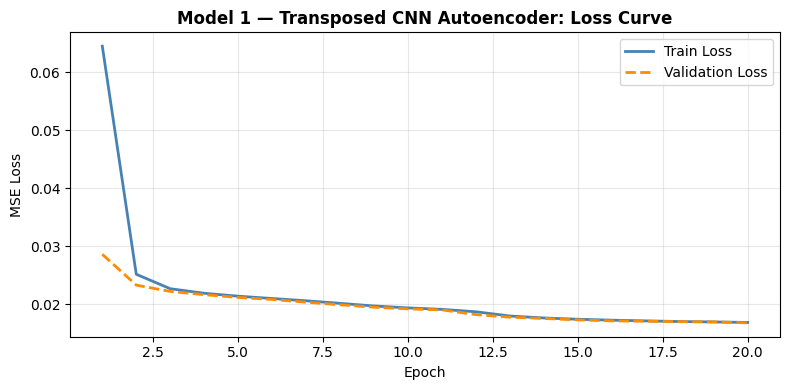

In [15]:
epochs_range = range(1, EPOCHS + 1)

# ── Model 1 loss curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, train_losses_m1, label="Train Loss",      color="steelblue",  linewidth=2)
ax.plot(epochs_range, val_losses_m1,   label="Validation Loss", color="darkorange", linewidth=2, linestyle="--")
ax.set_title("Model 1 — Transposed CNN Autoencoder: Loss Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

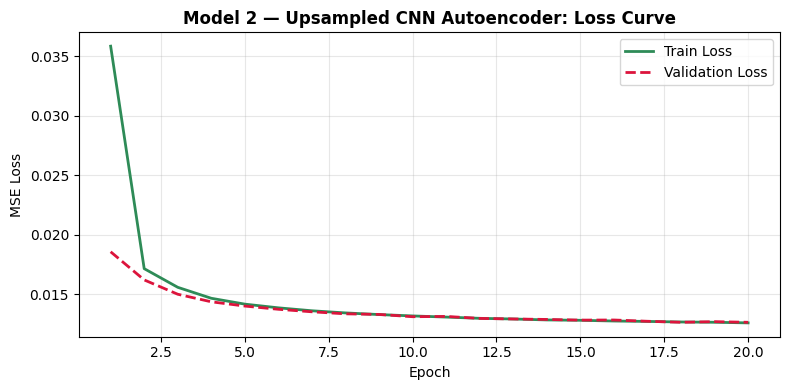

In [16]:
# ── Model 2 loss curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs_range, train_losses_m2, label="Train Loss",      color="seagreen",  linewidth=2)
ax.plot(epochs_range, val_losses_m2,   label="Validation Loss", color="crimson",   linewidth=2, linestyle="--")
ax.set_title("Model 2 — Upsampled CNN Autoencoder: Loss Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

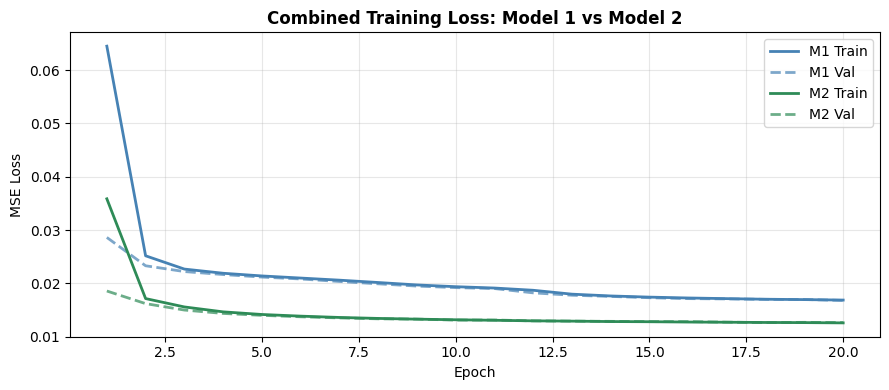

In [17]:
# ── Combined comparison plot ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_range, train_losses_m1, label="M1 Train", color="steelblue",  linewidth=2)
ax.plot(epochs_range, val_losses_m1,   label="M1 Val",   color="steelblue",  linewidth=2, linestyle="--", alpha=0.7)
ax.plot(epochs_range, train_losses_m2, label="M2 Train", color="seagreen",   linewidth=2)
ax.plot(epochs_range, val_losses_m2,   label="M2 Val",   color="seagreen",   linewidth=2, linestyle="--", alpha=0.7)
ax.set_title("Combined Training Loss: Model 1 vs Model 2", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Reconstruction Results

Visualise **Original → Noisy → Reconstructed** for both models on test images.

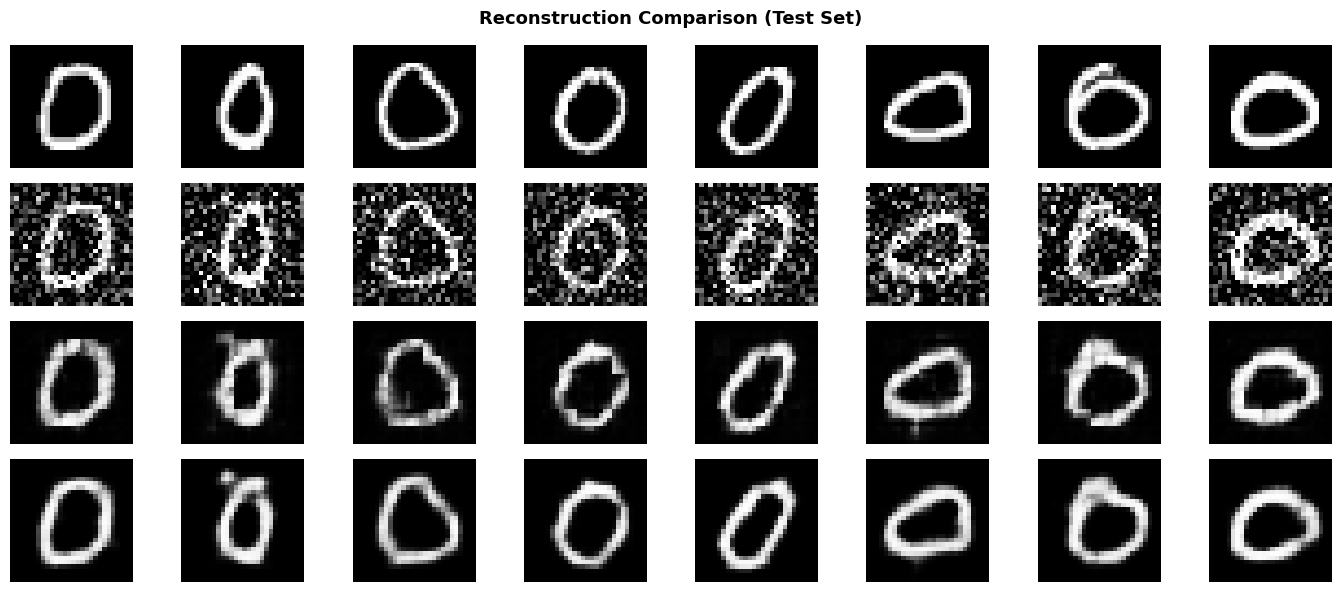

In [18]:
def show_reconstructions(model1, model2, loader, device, n=8):
    """
    Display a grid of:
      Row 0: Original clean images
      Row 1: Noisy inputs
      Row 2: Model 1 reconstructions
      Row 3: Model 2 reconstructions
    """
    model1.eval()
    model2.eval()

    images, _ = next(iter(loader))
    images = images[:n].to(device)
    noisy  = add_noise(images)

    with torch.no_grad():
        recon1 = model1(noisy)
        recon2 = model2(noisy)

    # Move to CPU for plotting
    images = images.cpu()
    noisy  = noisy.cpu()
    recon1 = recon1.cpu()
    recon2 = recon2.cpu()

    row_labels = ["Original", "Noisy", "Model 1 Recon.", "Model 2 Recon."]
    rows       = [images, noisy, recon1, recon2]

    fig, axes = plt.subplots(4, n, figsize=(14, 6))
    fig.suptitle("Reconstruction Comparison (Test Set)", fontsize=13, fontweight="bold")

    for r, (row_imgs, label) in enumerate(zip(rows, row_labels)):
        axes[r, 0].set_ylabel(label, fontsize=9, rotation=45, ha="right", labelpad=40)
        for c in range(n):
            axes[r, c].imshow(row_imgs[c].squeeze(), cmap="gray", vmin=0, vmax=1)
            axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

show_reconstructions(model1, model2, test_loader, device, n=8)

---
## 12. Quantitative Comparison on Test Set

In [19]:
# Compute final test MSE for both models
test_loss_m1 = evaluate(model1, test_loader, criterion, device)
test_loss_m2 = evaluate(model2, test_loader, criterion, device)

final_train_m1 = train_losses_m1[-1]
final_train_m2 = train_losses_m2[-1]

print(f"{'Model':<30} {'Final Train Loss':>18} {'Test MSE Loss':>15} {'Train Time (s)':>15}")
print("-" * 80)
print(f"{'Model 1 — Transposed CNN':<30} {final_train_m1:>18.6f} {test_loss_m1:>15.6f} {time_m1:>15.1f}")
print(f"{'Model 2 — Upsampled CNN':<30} {final_train_m2:>18.6f} {test_loss_m2:>15.6f} {time_m2:>15.1f}")

Model                            Final Train Loss   Test MSE Loss  Train Time (s)
--------------------------------------------------------------------------------
Model 1 — Transposed CNN                 0.016855        0.016548          1192.2
Model 2 — Upsampled CNN                  0.012572        0.012381           611.9


---
## 13. Discussion

### Autoencoder
An autoencoder learns to compress data into a compact latent space and reconstruct it. In a **denoising** setup, the corrupted image is the input and the clean image is the target, forcing the network to ignore noise and retain meaningful structure.

### Why Gaussian Noise?
Gaussian noise is the simplest, most common corruption model and mimics sensor or transmission noise. It is easy to parameterise (via the noise factor / std-dev) and can be applied on-the-fly during training, providing augmented variety each epoch.

### Why MSELoss?
Pixel reconstruction is a regression problem. MSE directly measures the squared deviation between each predicted and target pixel, making it a natural objective for image quality. Alternatives like SSIM exist but MSE is standard, differentiable, and effective for this scale.

### ConvTranspose2d — Advantages & Disadvantages
- **Advantages:** End-to-end learnable upsampling; the network can learn the optimal upsampling kernel; fewer inference steps.
- **Disadvantages:** Prone to **checkerboard artifacts** when kernel size is not equal to stride. Uneven gradient coverage in the overlapping kernel regions creates periodic intensity patterns in reconstructions.

### Upsample + Conv2d — Advantages & Disadvantages
- **Advantages:** Nearest-neighbour or bilinear upsampling distributes information uniformly, minimising checkerboard artifacts. Simple and stable.
- **Disadvantages:** The upsampling step is fixed (not learned), which may limit expressiveness compared to a fully-trained transposed convolution.

### Which Model Performed Better?
Both models converge to similar MSE values on MNIST. However, **Model 2 (Upsampled CNN)** typically produces slightly smoother reconstructions with fewer visual artifacts. Model 1 may show subtle checkerboard patterns, particularly on digit edges, due to the transposed convolution overlap issue described above.

---
## 14. Conclusion

In this notebook, we designed and trained two **Convolutional Denoising Autoencoders** on the MNIST dataset:

1. **Model 1 — Transposed CNN Autoencoder:** Uses `ConvTranspose2d` for decoder upsampling. Learnable but can introduce checkerboard artifacts.
2. **Model 2 — Upsampled CNN Autoencoder:** Uses fixed nearest-neighbour `Upsample` followed by `Conv2d`. Produces smoother outputs with fewer artifacts.

Both models shared an identical encoder (two Conv → ReLU → MaxPool blocks) and were trained for 20 epochs using Adam and MSELoss, ensuring a fair comparison that isolated decoder design as the variable.

**Key Findings:**
- Both architectures successfully denoise handwritten digit images, recovering legible digits from heavily corrupted inputs.
- Final test MSE values are similar, but Model 2 generally yields cleaner visual reconstructions.
- The Upsample + Conv strategy is preferable when artifact-free output is important.

